In [ ]:
import sys
import cv2
import numpy as np

In [ ]:
print("Python version")
print (sys.version)
print("Version info.")
print (sys.version_info)

Python version
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Version info.
sys.version_info(major=3, minor=13, micro=15, releaselevel='final', serial=0)


In [ ]:
print("OpenCV version")
print(cv2.__version__)

OpenCV version
4.14.0


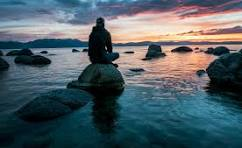

In [ ]:
from google.colab.patches import cv2_imshow
image = cv2.imread('sample.jfif')

if image is not None:
    cv2_imshow(image)
else:
    print("No image found")
    cv2.waitKey(0)
    cv2.destroyAllWindows()


In [ ]:
image = cv2.imread('sample.jfif')

if image is None:
    print("Image not found")
else:
    height, width = image.shape[:2]
    print("Height:", height)
    print("Width:", width)


Height: 148
Width: 242


In [ ]:
if len(image.shape) == 3:
    channels = image.shape[2]
    print("Number of channels:", channels)
else:
    print("Image is grayscale")

Number of channels: 3


In [ ]:
pixel = image[100,100]
print("Pixel at (100,100)",  pixel)

Pixel at (100,100) [3 4 2]


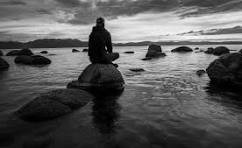

In [ ]:
if image is not None:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    cv2_imshow(image)
else:
    print("No image found")
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [ ]:
cv2.imwrite('gray_image.jpg', image)

True

Height: 200
Width: 200


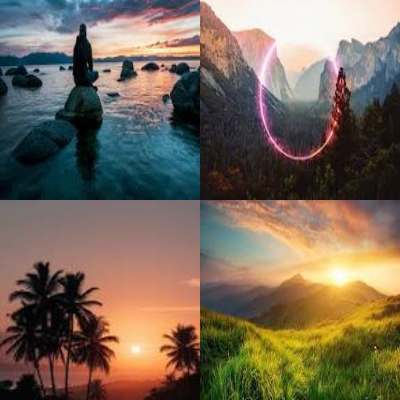

In [ ]:
from google.colab.patches import cv2_imshow


def load_and_prepare_image(filepath):
    img = cv2.imread(filepath)
    if img is None:
        print(f"Error: Image '{filepath}' not found.")
        return None
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif len(img.shape) == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
    return img

im1 = load_and_prepare_image('sample.jfif')
im2 = load_and_prepare_image('s2.jfif')
im3 = load_and_prepare_image('s3.jfif')
im4 = load_and_prepare_image('s4.jfif')


if any(img is None for img in [im1, im2, im3, im4]):
    print("Collage cannot be created due to missing or unreadable images.")
elif not all(img.shape[2] == 3 for img in [im1, im2, im3, im4]):
    print("Collage cannot be created as not all images are 3-channel BGR.")
else:
    height, width = 200,200
    size=(width,height)

    img1_resized = cv2.resize(im1, size)
    img2_resized = cv2.resize(im2, size)
    img3_resized = cv2.resize(im3, size)
    img4_resized = cv2.resize(im4, size)

    print("Height:", height)
    print("Width:", width)


    row1 = np.hstack((img1_resized, img2_resized))
    row2 = np.hstack((img3_resized, img4_resized))
    collage = np.vstack((row1, row2))

    cv2_imshow(collage)
    cv2.imwrite('final_collage.jpg', collage)


Original Image:


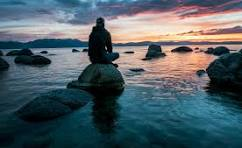


Image with Grayscale ROI:


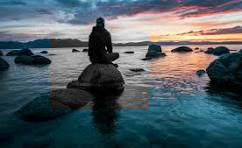

Modified image saved as 'image_with_gray_roi.jpg'


In [ ]:
original_image = cv2.imread('sample.jfif')

if original_image is None:
    print("Error: 'sample.jfif' not found. Please ensure the image is uploaded.")
else:

    x, y, w, h = 50, 30, 200, 80  #


    roi = original_image[y:y+h, x:x+w]

    gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    gray_roi_bgr = cv2.cvtColor(gray_roi, cv2.COLOR_GRAY2BGR)


    modified_image = original_image.copy()
    modified_image[y:y+h, x:x+w] = gray_roi_bgr

    print("Original Image:")
    cv2_imshow(original_image)
    print("\nImage with Grayscale ROI:")
    cv2_imshow(modified_image)

    cv2.imwrite('image_with_gray_roi.jpg', modified_image)
    print("Modified image saved as 'image_with_gray_roi.jpg'")


Original Grayscale Image:


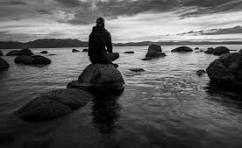


Binary Image with Threshold = 100:


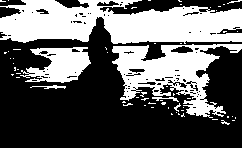


Binary Image with Threshold = 180:


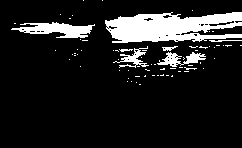

Binary images saved as 'binary_image_100.jpg' and 'binary_image_180.jpg'


In [ ]:
original_image = cv2.imread('sample.jfif', cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print("Error: 'sample.jfif' not found. Please ensure the image is uploaded.")
else:

    threshold_value_1 = 100
    threshold_value_2 = 180

    ret1, binary_image_1 = cv2.threshold(original_image, threshold_value_1, 255, cv2.THRESH_BINARY)

    ret2, binary_image_2 = cv2.threshold(original_image, threshold_value_2, 255, cv2.THRESH_BINARY)

    print(f"Original Grayscale Image:")
    cv2_imshow(original_image)

    print(f"\nBinary Image with Threshold = {threshold_value_1}:")
    cv2_imshow(binary_image_1)

    print(f"\nBinary Image with Threshold = {threshold_value_2}:")
    cv2_imshow(binary_image_2)

    cv2.imwrite('binary_image_100.jpg', binary_image_1)
    cv2.imwrite('binary_image_180.jpg', binary_image_2)
    print("Binary images saved as 'binary_image_100.jpg' and 'binary_image_180.jpg'")


In [ ]:
def report_image_properties(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"Error: Image '{image_path}' not found.")
        return

    print(f"\n--- Properties for '{image_path}' ---")
    height, width = img.shape[:2]
    print(f"Width: {width}")
    print(f"Height: {height}")

    if len(img.shape) == 3:
        channels = img.shape[2]
        print(f"Number of channels: {channels}")
    else:
        channels = 1
        print("Number of channels: 1 (Grayscale)")

    total_pixels = width * height * channels
    print(f"Total number of pixels: {total_pixels}")


report_image_properties('sample.jfif')
report_image_properties('s2.jfif')
report_image_properties('s3.jfif')



--- Properties for 'sample.jfif' ---
Width: 242
Height: 148
Number of channels: 3
Total number of pixels: 107448

--- Properties for 's2.jfif' ---
Width: 241
Height: 148
Number of channels: 3
Total number of pixels: 107004

--- Properties for 's3.jfif' ---
Width: 148
Height: 148
Number of channels: 3
Total number of pixels: 65712


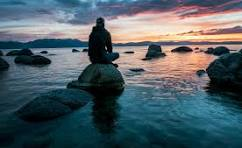


1: Gray, 2: Resize, 3: Crop, 4: Save, 5: Show, 6: Exit
Choice: 2
W: 121
H: 212

1: Gray, 2: Resize, 3: Crop, 4: Save, 5: Show, 6: Exit



KeyboardInterrupt



In [ ]:
def process_image_menu(path='sample.jfif'):
    img = cv2.imread(path)
    if img is None:
        print(f"Error: {path} not found.")
        return

    curr = img.copy()
    cv2_imshow(curr)

    while True:
        print("\n1: Gray, 2: Resize, 3: Crop, 4: Save, 5: Show, 6: Exit")
        c = input("Choice: ")

        if c == '1':
            if len(curr.shape) == 3:
                curr = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)
        elif c == '2':
            try:
                nw, nh = int(input("W: ")), int(input("H: "))
                curr = cv2.resize(curr, (nw, nh))
            except: pass
        elif c == '3':
            try:
                h_i, w_i = curr.shape[:2]
                x, y, w, h = int(input("X: ")), int(input("Y: ")), int(input("W: ")), int(input("H: "))
                if 0 <= x < w_i and 0 <= y < h_i:
                    curr = curr[y:y+h, x:x+w]
            except: pass
        elif c == '4':
            fn = input("Filename: ")
            if '.' not in fn: fn += '.jpg'
            cv2.imwrite(fn, curr)
        elif c == '5':
            cv2_imshow(curr)
        elif c == '6':
            break

process_image_menu('sample.jfif')